In [1]:
# 03. Baseline Model Training and Evaluation
import sys
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

sys.path.append('../src')
from preprocessing import build_dataset, VOCAB, CHAR_TO_IDX
from baseline import PeptideDataset, Encoder, Decoder

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if torch.backends.mps.is_available():
    device = torch.device('mps')
print(f"Using device: {device}")


/Users/akshaymohanrevankar/.matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-qaozmlti because there was an issue with the default path (/Users/akshaymohanrevankar/.matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Matplotlib is building the font cache; this may take a moment.


Using device: mps


In [2]:
# Configuration
MZML_PATH = "../../Peptide Sequencing-selected/Data/E coli EV proteomics/Ecoli_EV_1.mzML"
XLSX_PATH = "../../Peptide Sequencing-selected/Data/E coli EV proteomics/Database search output_Ecoli_EV_1.xlsx"


In [3]:
# 1. Load Data
print("Building dataset... (This extracts and preprocesses up to 2000 spectra)")
X, y = build_dataset(MZML_PATH, XLSX_PATH, max_spectra=2000)
print(f"Dataset shape: X={X.shape}, y={y.shape}")


Building dataset... (This extracts and preprocesses up to 2000 spectra)


Dataset shape: X=(1488, 20000), y=(1488, 32)


In [4]:
# 2. Train/Val/Test Split (70/15/15)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Train size: {len(X_train)}  Val size: {len(X_val)}  Test size: {len(X_test)}")

batch_size = 32
train_loader = DataLoader(PeptideDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(PeptideDataset(X_val, y_val), batch_size=batch_size)
test_loader = DataLoader(PeptideDataset(X_test, y_test), batch_size=batch_size)


Train size: 1041  Val size: 223  Test size: 224


In [5]:
# 3. Model Logic
class BaselineModel(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        
    def forward(self, src, trg):
        context = self.encoder(src)
        out = self.decoder(trg, context)
        return out

def calc_aa_recall(preds, targets):
    pred_classes = preds.argmax(dim=-1)
    mask = targets > 2 # ignore PAD(0), SOS(1), EOS(2)
    correct = (pred_classes == targets) & mask
    if mask.sum().item() == 0:
        return 0.0, 0
    return correct.sum().item(), mask.sum().item()

def calc_peptide_acc(preds, targets):
    pred_classes = preds.argmax(dim=-1)
    # Peptide accuracy: all tokens from first to EOS match
    acc_count = 0
    for i in range(targets.size(0)):
        p = pred_classes[i]
        t = targets[i]
        # Compare until EOS or PAD
        mask = t > 2
        if mask.sum() > 0 and torch.equal(p[mask], t[mask]):
            acc_count += 1
    return acc_count


In [6]:
# 4. Train LSTM Baseline (15 Epochs)
encoder_lstm = Encoder(input_dim=20000, context_dim=256)
decoder_lstm = Decoder(vocab_size=23, embed_dim=64, hidden_dim=256, context_dim=256, num_layers=2)
model_lstm = BaselineModel(encoder_lstm, decoder_lstm).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=0, label_smoothing=0.1)
optimizer_lstm = optim.Adam(model_lstm.parameters(), lr=1e-3, weight_decay=1e-5)

epochs = 15
lstm_train_losses = []
lstm_val_losses = []
lstm_val_recalls = []

best_val_loss = float('inf')
os.makedirs('../checkpoints', exist_ok=True)

print("--- Training LSTM Baseline ---")
for epoch in range(epochs):
    model_lstm.train()
    epoch_loss = 0
    for src, trg in train_loader:
        src, trg = src.to(device), trg.to(device)
        optimizer_lstm.zero_grad()
        
        trg_input = trg[:, :-1]
        trg_target = trg[:, 1:]
        
        output = model_lstm(src, trg_input)
        loss = criterion(output.reshape(-1, output.shape[-1]), trg_target.reshape(-1))
        loss.backward()
        nn.utils.clip_grad_norm_(model_lstm.parameters(), max_norm=1.0)
        optimizer_lstm.step()
        epoch_loss += loss.item()
        
    train_loss = epoch_loss / len(train_loader)
    lstm_train_losses.append(train_loss)
    
    # Validation
    model_lstm.eval()
    val_loss = 0
    correct_aa = 0
    total_aa = 0
    
    with torch.no_grad():
        for src, trg in val_loader:
            src, trg = src.to(device), trg.to(device)
            trg_input = trg[:, :-1]
            trg_target = trg[:, 1:]
            
            output = model_lstm(src, trg_input)
            loss = criterion(output.reshape(-1, output.shape[-1]), trg_target.reshape(-1))
            val_loss += loss.item()
            
            c, t = calc_aa_recall(output, trg_target)
            correct_aa += c
            total_aa += t
            
    val_loss /= len(val_loader)
    val_recall = correct_aa / total_aa if total_aa > 0 else 0
    
    lstm_val_losses.append(val_loss)
    lstm_val_recalls.append(val_recall)
    
    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val AA Recall: {val_recall:.4f}")
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        try:
            torch.save(model_lstm.state_dict(), '../checkpoints/baseline_best.pt')
        except: pass


--- Training LSTM Baseline ---


2026-03-28 20:51:38.843 Python[55713:3323957] Error creating directory 
 You don‚Äôt have permission. You don‚Äôt have permission to save the file ‚Äúmpsgraph-55713-2026-03-28_20_51_38-34781965‚Äù in the folder ‚Äúcom.apple.MetalPerformanceShadersGraph‚Äù.
2026-03-28 20:51:38.895 Python[55713:3323957] Error creating directory 
 You don‚Äôt have permission. You don‚Äôt have permission to save the file ‚Äúmpsgraph-55713-2026-03-28_20_51_38-3825145558‚Äù in the folder ‚Äúcom.apple.MetalPerformanceShadersGraph‚Äù.
2026-03-28 20:51:38.937 Python[55713:3323957] Error creating directory 
 You don‚Äôt have permission. You don‚Äôt have permission to save the file ‚Äúmpsgraph-55713-2026-03-28_20_51_38-2354891869‚Äù in the folder ‚Äúcom.apple.MetalPerformanceShadersGraph‚Äù.


2026-03-28 20:51:39.274 Python[55713:3323957] Error creating directory 
 You don‚Äôt have permission. You don‚Äôt have permission to save the file ‚Äúmpsgraph-55713-2026-03-28_20_51_39-754012948‚Äù in the folder ‚Äúcom.apple.MetalPerformanceShadersGraph‚Äù.
2026-03-28 20:51:39.277 Python[55713:3323957] Error creating directory 
 You don‚Äôt have permission. You don‚Äôt have permission to save the file ‚Äúmpsgraph-55713-2026-03-28_20_51_39-1723098885‚Äù in the folder ‚Äúcom.apple.MetalPerformanceShadersGraph‚Äù.


2026-03-28 20:51:39.758 Python[55713:3323957] Error creating directory 
 You don‚Äôt have permission. You don‚Äôt have permission to save the file ‚Äúmpsgraph-55713-2026-03-28_20_51_39-1257870198‚Äù in the folder ‚Äúcom.apple.MetalPerformanceShadersGraph‚Äù.
2026-03-28 20:51:39.835 Python[55713:3323957] Error creating directory 
 You don‚Äôt have permission. You don‚Äôt have permission to save the file ‚Äúmpsgraph-55713-2026-03-28_20_51_39-33938584‚Äù in the folder ‚Äúcom.apple.MetalPerformanceShadersGraph‚Äù.
2026-03-28 20:51:39.895 Python[55713:3323957] Error creating directory 
 You don‚Äôt have permission. You don‚Äôt have permission to save the file ‚Äúmpsgraph-55713-2026-03-28_20_51_39-543046750‚Äù in the folder ‚Äúcom.apple.MetalPerformanceShadersGraph‚Äù.


2026-03-28 20:51:40.530 Python[55713:3323957] Error creating directory 
 You don‚Äôt have permission. You don‚Äôt have permission to save the file ‚Äúmpsgraph-55713-2026-03-28_20_51_40-3205008611‚Äù in the folder ‚Äúcom.apple.MetalPerformanceShadersGraph‚Äù.


...

Epoch 11/15 | Train Loss: 2.3979 | Val Loss: 2.6041 | Val AA Recall: 0.1980


Epoch 12/15 | Train Loss: 2.3405 | Val Loss: 2.5597 | Val AA Recall: 0.2148


Epoch 13/15 | Train Loss: 2.2777 | Val Loss: 2.5965 | Val AA Recall: 0.2254


Epoch 14/15 | Train Loss: 2.2221 | Val Loss: 2.5180 | Val AA Recall: 0.2531


Epoch 15/15 | Train Loss: 2.1459 | Val Loss: 2.5144 | Val AA Recall: 0.2825


In [7]:
# 5. GRU Ablation Study
class DecoderGRU(nn.Module):
    def __init__(self, vocab_size=23, embed_dim=64, hidden_dim=256, context_dim=256, num_layers=2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.rnn = nn.GRU(input_size=embed_dim + context_dim, hidden_size=hidden_dim, num_layers=num_layers, batch_first=True)
        self.fc_out = nn.Linear(hidden_dim, vocab_size)
    def forward(self, trg, context):
        embedded = self.embedding(trg)
        seq_len = trg.shape[1]
        context_repeated = context.unsqueeze(1).repeat(1, seq_len, 1)
        rnn_input = torch.cat((embedded, context_repeated), dim=2)
        outputs, _ = self.rnn(rnn_input)
        return self.fc_out(outputs)

encoder_gru = Encoder(input_dim=20000, context_dim=256)
decoder_gru = DecoderGRU(vocab_size=23, embed_dim=64, hidden_dim=256, context_dim=256, num_layers=2)
model_gru = BaselineModel(encoder_gru, decoder_gru).to(device)

optimizer_gru = optim.Adam(model_gru.parameters(), lr=1e-3, weight_decay=1e-5)

print("\n--- Training GRU Ablation ---")
for epoch in range(epochs):
    model_gru.train()
    for src, trg in train_loader:
        src, trg = src.to(device), trg.to(device)
        optimizer_gru.zero_grad()
        output = model_gru(src, trg[:, :-1])
        loss = criterion(output.reshape(-1, output.shape[-1]), trg[:, 1:].reshape(-1))
        loss.backward()
        nn.utils.clip_grad_norm_(model_gru.parameters(), max_norm=1.0)
        optimizer_gru.step()
    
    model_gru.eval()
    val_loss = 0
    with torch.no_grad():
        for src, trg in val_loader:
            src, trg = src.to(device), trg.to(device)
            output = model_gru(src, trg[:, :-1])
            loss = criterion(output.reshape(-1, output.shape[-1]), trg[:, 1:].reshape(-1))
            val_loss += loss.item()
    if epoch == epochs-1:
        print(f"GRU final Val Loss: {val_loss/len(val_loader):.4f}")



--- Training GRU Ablation ---


2026-03-28 20:51:59.360 Python[55713:3323957] Error creating directory 
 You don‚Äôt have permission. You don‚Äôt have permission to save the file ‚Äúmpsgraph-55713-2026-03-28_20_51_59-1270910395‚Äù in the folder ‚Äúcom.apple.MetalPerformanceShadersGraph‚Äù.
2026-03-28 20:51:59.478 Python[55713:3323957] Error creating directory 
 You don‚Äôt have permission. You don‚Äôt have permission to save the file ‚Äúmpsgraph-55713-2026-03-28_20_51_59-1099467087‚Äù in the folder ‚Äúcom.apple.MetalPerformanceShadersGraph‚Äù.


2026-03-28 20:51:59.566 Python[55713:3324554] Error creating directory 
 You don‚Äôt have permission. You don‚Äôt have permission to save the file ‚Äúmpsgraph-55713-2026-03-28_20_51_59-1039202066‚Äù in the folder ‚Äúcom.apple.MetalPerformanceShadersGraph‚Äù.
2026-03-28 20:51:59.625 Python[55713:3324554] Error creating directory 
 You don‚Äôt have permission. You don‚Äôt have permission to save the file ‚Äúmpsgraph-55713-2026-03-28_20_51_59-1709768844‚Äù in the folder ‚Äúcom.apple.MetalPerformanceShadersGraph‚Äù.
2026-03-28 20:51:59.682 Python[55713:3324554] Error creating directory 
 You don‚Äôt have permission. You don‚Äôt have permission to save the file ‚Äúmpsgraph-55713-2026-03-28_20_51_59-1653524342‚Äù in the folder ‚Äúcom.apple.MetalPerformanceShadersGraph‚Äù.
2026-03-28 20:51:59.684 Python[55713:3324554] Error creating directory 
 You don‚Äôt have permission. You don‚Äôt have permission to save the file ‚Äúmpsgraph-55713-2026-03-28_20_51_59-2807861218‚Äù in the folder ‚Äúcom.app

2026-03-28 20:51:59.768 Python[55713:3324554] Error creating directory 
 You don‚Äôt have permission. You don‚Äôt have permission to save the file ‚Äúmpsgraph-55713-2026-03-28_20_51_59-274198049‚Äù in the folder ‚Äúcom.apple.MetalPerformanceShadersGraph‚Äù.
2026-03-28 20:51:59.771 Python[55713:3324554] Error creating directory 
 You don‚Äôt have permission. You don‚Äôt have permission to save the file ‚Äúmpsgraph-55713-2026-03-28_20_51_59-2820926342‚Äù in the folder ‚Äúcom.apple.MetalPerformanceShadersGraph‚Äù.
2026-03-28 20:51:59.783 Python[55713:3323957] Error creating directory 
 You don‚Äôt have permission. You don‚Äôt have permission to save the file ‚Äúmpsgraph-55713-2026-03-28_20_51_59-1541032133‚Äù in the folder ‚Äúcom.apple.MetalPerformanceShadersGraph‚Äù.
2026-03-28 20:51:59.787 Python[55713:3323957] Error creating directory 
 You don‚Äôt have permission. You don‚Äôt have permission to save the file ‚Äúmpsgraph-55713-2026-03-28_20_51_59-3409428308‚Äù in the folder ‚Äúcom.appl

2026-03-28 20:52:00.972 Python[55713:3323957] Error creating directory 
 You don‚Äôt have permission. You don‚Äôt have permission to save the file ‚Äúmpsgraph-55713-2026-03-28_20_52_00-3549337773‚Äù in the folder ‚Äúcom.apple.MetalPerformanceShadersGraph‚Äù.
2026-03-28 20:52:01.058 Python[55713:3323957] Error creating directory 
 You don‚Äôt have permission. You don‚Äôt have permission to save the file ‚Äúmpsgraph-55713-2026-03-28_20_52_01-2748209078‚Äù in the folder ‚Äúcom.apple.MetalPerformanceShadersGraph‚Äù.
2026-03-28 20:52:01.138 Python[55713:3324554] Error creating directory 
 You don‚Äôt have permission. You don‚Äôt have permission to save the file ‚Äúmpsgraph-55713-2026-03-28_20_52_01-3221821292‚Äù in the folder ‚Äúcom.apple.MetalPerformanceShadersGraph‚Äù.
2026-03-28 20:52:01.140 Python[55713:3324554] Error creating directory 
 You don‚Äôt have permission. You don‚Äôt have permission to save the file ‚Äúmpsgraph-55713-2026-03-28_20_52_01-900617167‚Äù in the folder ‚Äúcom.appl

2026-03-28 20:52:01.239 Python[55713:3324554] Error creating directory 
 You don‚Äôt have permission. You don‚Äôt have permission to save the file ‚Äúmpsgraph-55713-2026-03-28_20_52_01-3806954017‚Äù in the folder ‚Äúcom.apple.MetalPerformanceShadersGraph‚Äù.
2026-03-28 20:52:01.243 Python[55713:3324554] Error creating directory 
 You don‚Äôt have permission. You don‚Äôt have permission to save the file ‚Äúmpsgraph-55713-2026-03-28_20_52_01-3276786555‚Äù in the folder ‚Äúcom.apple.MetalPerformanceShadersGraph‚Äù.
2026-03-28 20:52:01.337 Python[55713:3323957] Error creating directory 
 You don‚Äôt have permission. You don‚Äôt have permission to save the file ‚Äúmpsgraph-55713-2026-03-28_20_52_01-1468436347‚Äù in the folder ‚Äúcom.apple.MetalPerformanceShadersGraph‚Äù.
2026-03-28 20:52:01.347 Python[55713:3323957] Error creating directory 
 You don‚Äôt have permission. You don‚Äôt have permission to save the file ‚Äúmpsgraph-55713-2026-03-28_20_52_01-2733883625‚Äù in the folder ‚Äúcom.app

GRU final Val Loss: 2.2396


In [8]:
# 6. Test Evaluation & Final Metrics
def evaluate_test(model):
    model.eval()
    correct_aa, total_aa = 0, 0
    pep_acc = 0
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for src, trg in test_loader:
            src, trg = src.to(device), trg.to(device)
            output = model(src, trg[:, :-1])
            
            c, t = calc_aa_recall(output, trg[:, 1:])
            correct_aa += c
            total_aa += t
            pep_acc += calc_peptide_acc(output, trg[:, 1:])
            
            preds = output.argmax(dim=-1)
            # Mask to gather valid tokens
            mask = trg[:, 1:] > 2
            for i in range(targets.size(0) if 'targets' in locals() else trg.size(0)):
                all_preds.extend(preds[i][mask[i]].cpu().numpy().tolist())
                all_targets.extend(trg[i, 1:][mask[i]].cpu().numpy().tolist())
                
    aa_recall = (correct_aa / total_aa) if total_aa > 0 else 0
    peptide_acc = pep_acc / len(test_loader.dataset)
    return aa_recall, peptide_acc, all_preds, all_targets

# Re-load best LSTM for evaluation
try: model_lstm.load_state_dict(torch.load('../checkpoints/baseline_best.pt'))
except: pass

lstm_test_recall, lstm_test_pep_acc, lstm_preds, lstm_targs = evaluate_test(model_lstm)
gru_test_recall, gru_test_pep_acc, _, _ = evaluate_test(model_gru)

results = pd.DataFrame({
    'Model Variant': ['LSTM (Baseline)', 'GRU (Ablation)'],
    'Train Loss (Final)': [lstm_train_losses[-1], 'N/A'],
    'Val Loss (Final)': [lstm_val_losses[-1], 'N/A'],
    'Test AA Recall (%)': [lstm_test_recall*100, gru_test_recall*100],
    'Test Peptide Acc (%)': [lstm_test_pep_acc*100, gru_test_pep_acc*100]
})

print("\n=== Final Metrics Table ===")
display(results)


2026-03-28 20:52:19.317 Python[55713:3323957] Error creating directory 
 You don‚Äôt have permission. You don‚Äôt have permission to save the file ‚Äúmpsgraph-55713-2026-03-28_20_52_19-3872072508‚Äù in the folder ‚Äúcom.apple.MetalPerformanceShadersGraph‚Äù.
2026-03-28 20:52:19.401 Python[55713:3323957] Error creating directory 
 You don‚Äôt have permission. You don‚Äôt have permission to save the file ‚Äúmpsgraph-55713-2026-03-28_20_52_19-4270454576‚Äù in the folder ‚Äúcom.apple.MetalPerformanceShadersGraph‚Äù.
2026-03-28 20:52:19.404 Python[55713:3323957] Error creating directory 
 You don‚Äôt have permission. You don‚Äôt have permission to save the file ‚Äúmpsgraph-55713-2026-03-28_20_52_19-245815880‚Äù in the folder ‚Äúcom.apple.MetalPerformanceShadersGraph‚Äù.
2026-03-28 20:52:19.488 Python[55713:3323957] Error creating directory 
 You don‚Äôt have permission. You don‚Äôt have permission to save the file ‚Äúmpsgraph-55713-2026-03-28_20_52_19-2810895244‚Äù in the folder ‚Äúcom.appl

2026-03-28 20:52:19.655 Python[55713:3323957] Error creating directory 
 You don‚Äôt have permission. You don‚Äôt have permission to save the file ‚Äúmpsgraph-55713-2026-03-28_20_52_19-1836576052‚Äù in the folder ‚Äúcom.apple.MetalPerformanceShadersGraph‚Äù.


2026-03-28 20:52:21.585 Python[55713:3323957] Error creating directory 
 You don‚Äôt have permission. You don‚Äôt have permission to save the file ‚Äúmpsgraph-55713-2026-03-28_20_52_21-3755726017‚Äù in the folder ‚Äúcom.apple.MetalPerformanceShadersGraph‚Äù.
2026-03-28 20:52:21.667 Python[55713:3323957] Error creating directory 
 You don‚Äôt have permission. You don‚Äôt have permission to save the file ‚Äúmpsgraph-55713-2026-03-28_20_52_21-2972017321‚Äù in the folder ‚Äúcom.apple.MetalPerformanceShadersGraph‚Äù.


2026-03-28 20:52:21.960 Python[55713:3323957] Error creating directory 
 You don‚Äôt have permission. You don‚Äôt have permission to save the file ‚Äúmpsgraph-55713-2026-03-28_20_52_21-1944517163‚Äù in the folder ‚Äúcom.apple.MetalPerformanceShadersGraph‚Äù.
2026-03-28 20:52:21.963 Python[55713:3323957] Error creating directory 
 You don‚Äôt have permission. You don‚Äôt have permission to save the file ‚Äúmpsgraph-55713-2026-03-28_20_52_21-239137268‚Äù in the folder ‚Äúcom.apple.MetalPerformanceShadersGraph‚Äù.
2026-03-28 20:52:21.970 Python[55713:3323957] Error creating directory 
 You don‚Äôt have permission. You don‚Äôt have permission to save the file ‚Äúmpsgraph-55713-2026-03-28_20_52_21-1116874190‚Äù in the folder ‚Äúcom.apple.MetalPerformanceShadersGraph‚Äù.
2026-03-28 20:52:21.972 Python[55713:3323957] Error creating directory 
 You don‚Äôt have permission. You don‚Äôt have permission to save the file ‚Äúmpsgraph-55713-2026-03-28_20_52_21-3954288905‚Äù in the folder ‚Äúcom.appl

2026-03-28 20:52:22.182 Python[55713:3323957] Error creating directory 
 You don‚Äôt have permission. You don‚Äôt have permission to save the file ‚Äúmpsgraph-55713-2026-03-28_20_52_22-1523040806‚Äù in the folder ‚Äúcom.apple.MetalPerformanceShadersGraph‚Äù.
2026-03-28 20:52:22.185 Python[55713:3323957] Error creating directory 
 You don‚Äôt have permission. You don‚Äôt have permission to save the file ‚Äúmpsgraph-55713-2026-03-28_20_52_22-3453033646‚Äù in the folder ‚Äúcom.apple.MetalPerformanceShadersGraph‚Äù.
2026-03-28 20:52:22.209 Python[55713:3323957] Error creating directory 
 You don‚Äôt have permission. You don‚Äôt have permission to save the file ‚Äúmpsgraph-55713-2026-03-28_20_52_22-803850860‚Äù in the folder ‚Äúcom.apple.MetalPerformanceShadersGraph‚Äù.
2026-03-28 20:52:22.212 Python[55713:3323957] Error creating directory 
 You don‚Äôt have permission. You don‚Äôt have permission to save the file ‚Äúmpsgraph-55713-2026-03-28_20_52_22-1025661302‚Äù in the folder ‚Äúcom.appl

2026-03-28 20:52:22.511 Python[55713:3323957] Error creating directory 
 You don‚Äôt have permission. You don‚Äôt have permission to save the file ‚Äúmpsgraph-55713-2026-03-28_20_52_22-1280144152‚Äù in the folder ‚Äúcom.apple.MetalPerformanceShadersGraph‚Äù.
2026-03-28 20:52:22.514 Python[55713:3323957] Error creating directory 
 You don‚Äôt have permission. You don‚Äôt have permission to save the file ‚Äúmpsgraph-55713-2026-03-28_20_52_22-3472628341‚Äù in the folder ‚Äúcom.apple.MetalPerformanceShadersGraph‚Äù.



=== Final Metrics Table ===


,Model Variant,Train Loss (Final),Val Loss (Final),Test AA Recall (%),Test Peptide Acc (%)
0,LSTM (Baseline),2.145883,2.514402,27.951153,0.446429
1,GRU (Ablation),N/A,N/A,43.656716,8.035714


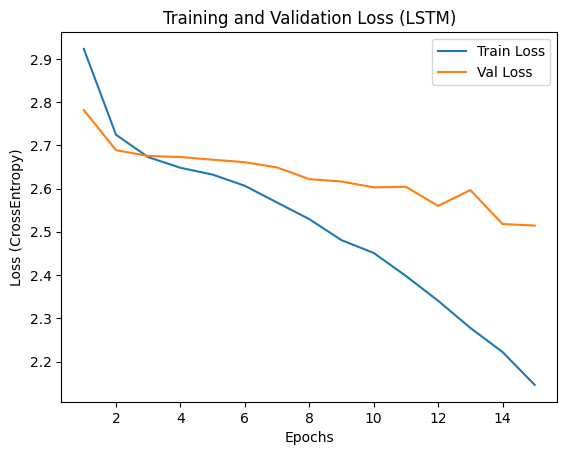

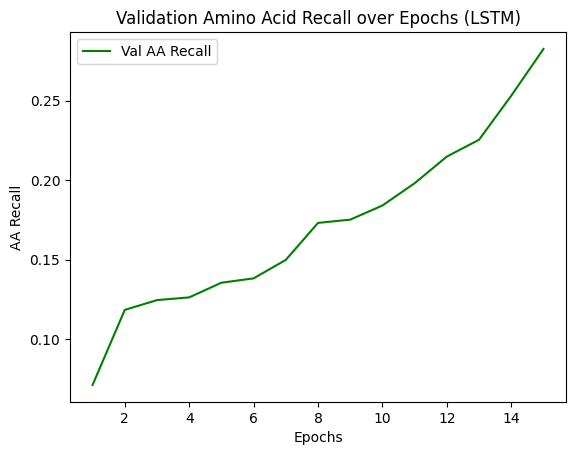

In [9]:
# 7. Plots (Loss and AA Recall Curves)
plt.figure()
plt.plot(range(1, epochs+1), lstm_train_losses, label='Train Loss')
plt.plot(range(1, epochs+1), lstm_val_losses, label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (CrossEntropy)')
plt.title('Training and Validation Loss (LSTM)')
plt.legend()
plt.savefig('../figures/eda/training_loss.png')
plt.show()

plt.figure()
plt.plot(range(1, epochs+1), lstm_val_recalls, color='green', label='Val AA Recall')
plt.xlabel('Epochs')
plt.ylabel('AA Recall')
plt.title('Validation Amino Acid Recall over Epochs (LSTM)')
plt.legend()
plt.savefig('../figures/eda/aa_recall_curve.png')
plt.show()


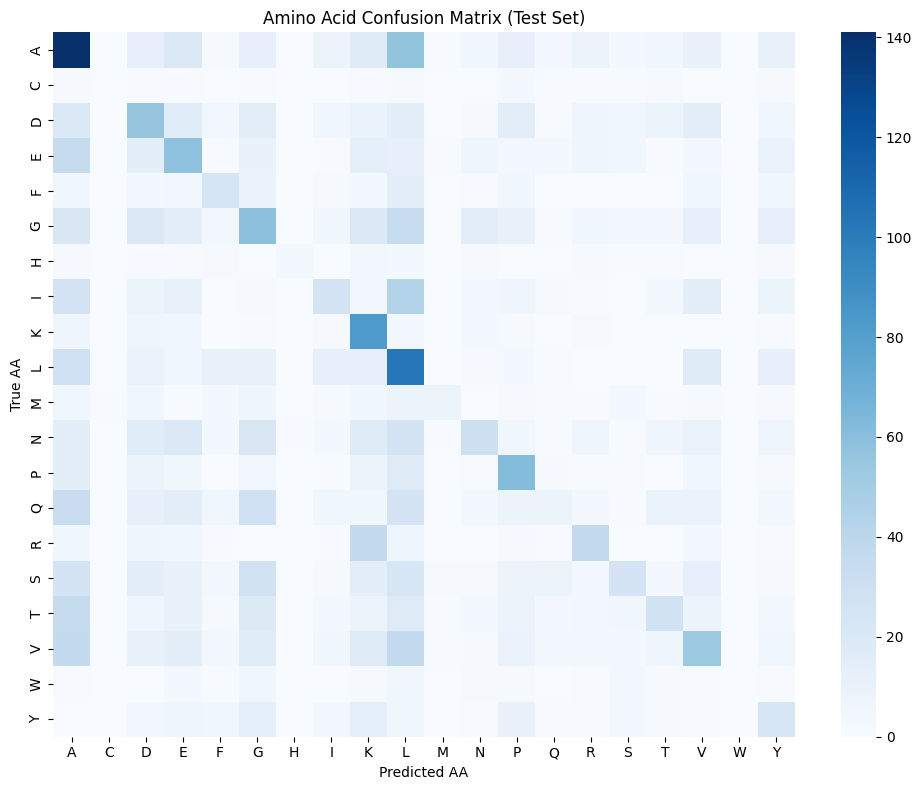

In [10]:
# 8. Confusion Matrix over Amino Acids
cm = confusion_matrix(lstm_targs, lstm_preds, labels=range(3, 23))

# Label names
labels = [VOCAB[i-3] for i in range(3, 23)]

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=False, cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title("Amino Acid Confusion Matrix (Test Set)")
plt.xlabel("Predicted AA")
plt.ylabel("True AA")
plt.tight_layout()
plt.savefig('../figures/eda/confusion_matrix.png')
plt.show()


In [11]:
# 9. 10 Prediction Examples
IDX_TO_CHAR = {v: k for k, v in CHAR_TO_IDX.items()}
IDX_TO_CHAR[0] = ''
IDX_TO_CHAR[1] = '<SOS>'
IDX_TO_CHAR[2] = '<EOS>'

def decode_sequence(tokens):
    return "".join([IDX_TO_CHAR.get(t.item(), "") if isinstance(t, torch.Tensor) else IDX_TO_CHAR.get(t, "") for t in tokens if t not in [0, 1, 2]])

print("\n--- 10 Prediction Examples (LSTM Baseline) ---")
with torch.no_grad():
    count = 0
    for src, trg in test_loader:
        src, trg = src.to(device), trg.to(device)
        output = model_lstm(src, trg[:, :-1])
        preds = output.argmax(dim=-1)
        
        for i in range(preds.size(0)):
            pred_seq = decode_sequence(preds[i])
            true_seq = decode_sequence(trg[i, 1:])
            print(f"Ground Truth: {true_seq:15s} | Predicted: {pred_seq:15s}")
            count += 1
            if count == 10:
                break
        if count == 10: break



--- 10 Prediction Examples (LSTM Baseline) ---
Ground Truth: AVAAGMNPMDLK    | Predicted: AGTGGFVPRKKKKKKKKKKKKKKKKKKKKK
Ground Truth: MIQEQTMLNVADNSGAR | Predicted: GADMGGPPDDDDKKKKKVKKKKKKKKKKKK
Ground Truth: DDEVIVLTGK      | Predicted: VALLLMVARKRKKKKKKKKKKKKKKKKKKK


2026-03-28 20:52:23.894 Python[55713:3323957] Error creating directory 
 You don‚Äôt have permission. You don‚Äôt have permission to save the file ‚Äúmpsgraph-55713-2026-03-28_20_52_23-1992422900‚Äù in the folder ‚Äúcom.apple.MetalPerformanceShadersGraph‚Äù.


Ground Truth: DAQSALTVSETTFGR | Predicted: TALLVLTQQEVFFRRRRRRRRRRRRRRRRR
Ground Truth: VDQLSNDVNAMR    | Predicted: TDGLSNDVAAMRRRRRRRRRRRRRRRRRRR
Ground Truth: TIVSDGKPQTDNDTGMISYK | Predicted: TDDDDGDPDTDTTTLMVSYKVKKKKKKKKK
Ground Truth: VDQLSNDVNAMR    | Predicted: VDGLSNDVTAMRRRRRRRRRRRRRRRRRRR
Ground Truth: EISMSIK         | Predicted: AADDAAARRKKKKKKKKKKKKKKKKKKKKK
Ground Truth: SLEQYFGR        | Predicted: GDDGYFRRRKKKKKKKKKKKKKKKKKKKKK
Ground Truth: SALVIQTLANGAVR  | Predicted: LLLTAAAAEKKKKKKKKKKKKKKKKKKKKK
